In [3]:
import numpy as np
import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchmetrics
import kornia.augmentation as K

In [94]:
PROJECT_ROOT = Path().resolve().parent
datetime_now = datetime.datetime.now()
date = datetime_now.strftime("%Y-%m-%d")

loss_curve_fp = PROJECT_ROOT / "outputs/plots/loss_curves" / f"loss_curve_{date}.png"

SEED= 42
torch.manual_seed(SEED)

In [ ]:
# def load_patch_dict_as_tensor(Patch_dict):
    
#     # try first as a for loop and then see if can switch to comprehension

#     band_names = ["B2", "B3", "B4", "B5", "B6"]

#     feature_list = Patch_dict["features"]

#     patch_list = []0
#     label_list = []
#     location_list = []

#     for feat in feature_list:

#         band_arrays = [np.array(feat["properties"][band]) for band in band_names]
#         stacked_patch = np.stack(band_arrays) # (C,H,W)

#         patch_list.append(stacked_patch)
#         label_list.append(feat["properties"]["lc"])
#         location_list.append(feat["properties"]["location"])

#     patches = np.stack(patch_list) # (N, C, H, W)
#     patches = torch.from_numpy(patches).float()

#     labels= torch.tensor(label_list).long()
#     locations = np.array(location_list) # array for easier boolean masking but no need for tensor


#     return patches, labels, locations

In [57]:
patches_path = PROJECT_ROOT / "outputs/15px_patches" / "combined_15px_patches.geojson"

with open(patches_path, "r") as f:
    patches = json.load(f)


In [ ]:
# Version using comprehension

def load_patch_dict_as_tensor(Patch_dict, band_list = None):
    if not band_list:
        band_list = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

    feature_list = Patch_dict["features"]

    patches = np.stack([
        np.stack([np.array(F["properties"][band]) for band in band_list]) # (N, C, H, W) which is what pytorch expects
        for F in feature_list  
    ])

    labels = torch.tensor([F["properties"]["lc"] for F in feature_list]).float().unsqueeze(1) # BCElogits loss will need to compare labels to float logits or probabilties
    # .unsqueeze(1) changes the shape from ([0,1,1,0]) to ([0],[1],[1],[0]) aka (B,) to (B, 1), need this for the criterion. 

    locations = np.array([F["properties"]["location"] for F in feature_list]) # array for easier boolean masking but no need for tensor

    class_int = np.array([F["properties"]["class_int"] for F in feature_list])
    
    label_id = np.array([F["properties"]["label_id"] for F in feature_list])

    patches = torch.from_numpy(patches).float()


    return patches, labels, locations, class_int, label_id

patches, labels, locations, class_int, label_id = load_patch_dict_as_tensor(patches, band_list= None)

# check the shape

print(patches.shape)


torch.Size([16189, 10, 15, 15])


In [59]:
print(labels.shape)
print(label_id[12000])

torch.Size([16189, 1])
VA0135_20230317


In [60]:
# next need to calcualte the mean and std for just the train region, can create a test_mask and val_mask and then train_masl = ~test_mask & ~val_mask

test_region = "Valsequillo"
val_region = "RawaPening"

test_mask = locations == test_region
val_mask = locations == val_region

train_mask = ~test_mask & ~ val_mask

train_patches, train_labels = patches[train_mask], labels[train_mask]
val_patches, val_labels = patches[val_mask], labels[val_mask]
test_patches, test_labels, test_labels_ids = patches[test_mask], labels[test_mask], label_id[test_mask]


mean = train_patches.mean(dim= (0,2,3)) # will average over the 0,2,3 axes and keep the 1 axis (channels / bands) separate. output shape (C,)
std = train_patches.std(dim = (0,2,3))

# mean = torch.tensor(mean).view(1,-1,1,1) # changes mean from (C,) to (1,C,1,1)
# std = torch.tensor(std).view(1,-1,1,1)

# standardise all the patches using the mean and std from the train patches - np maybe do this for each patch in the dataset in __getitem__?

# std_train_patches = (train_patches - mean)/std
# std_val_patches = (val_patches-mean)/std
# std_test_patches = (test_patches-mean)/ std




In [72]:
print(val_labels.shape)
print(test_labels_ids.shape)
print(type(test_labels_ids))
print(test_labels.shape)

torch.Size([2002, 1])
(2040,)
<class 'numpy.ndarray'>
torch.Size([2040, 1])


In [ ]:
### Might need to unsqueeze label ids and cals int. What shape wil the predicitons be? These three are all np.,arrays at this point (B,)

In [35]:

class PatchDataset(Dataset):
    def __init__(self, patches, labels, mean, std):
        
        mean = mean.detach().clone().view(1,-1,1,1) # changes from (C,) to (1,C,1,1)
        std = std.detach().clone().view(1,-1,1,1)
    
        self.patches = (patches - mean)/std 
        self.labels = labels 

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        return self.patches[idx], self.labels[idx]
    


    
train_dataset = PatchDataset(patches = train_patches, labels = train_labels, mean = mean, std = std)

train_loader = DataLoader(
    dataset= train_dataset,
    shuffle= True,
    batch_size= 32,
    num_workers= 0,
    pin_memory= True
    )
    
val_dataset = PatchDataset(patches = val_patches,labels= val_labels, mean = mean, std = std)

val_loader = DataLoader(
    dataset= val_dataset,
    shuffle= False,
    batch_size= 32,
    num_workers= 0,
    pin_memory= True
    )

# # --- Device selection ---
# # Colab (with a GPU runtime: Runtime > Change runtime type > GPU):
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Apple Silicon (M1/M2/M3/M4), using the Metal Performance Shaders backend:
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Portable version that works on either without editing — checks cuda, then mps, then falls back to cpu:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

aug = K.AugmentationSequential(
    K.RandomRotation(degrees = 90.0, p =0.5),
    K.RandomHorizontalFlip(p= 0.25),
    K.RandomVerticalFlip(p= 0.25),
    data_keys= ['input']).to(device)

# for epoch in len(number_epochs):
#     # Training
#     #-----------------------
#     model.train()

#     for batch_X, batch_y in train_loader:
#         batch_X = batch_X.to(device)
#         batch_y = batch_y.to(device)

#         batch_X = aug(batch_X) # Augment only in the train split

#         optimizer.zero_grad()
#         output = model(batch_x)
#         loss = criterion(output, batch_y)
#         loss.backwards()
#         optimizer.step()

#     # Val
#     #-----------------------

#     model.eval()

#     with torch.no_grad():
#         for batch_X, batch_y in val_loader:
            
#             batch_X = batch_X.to(device)
#             batch_y = batch_y.to(device)

#             output = model(batch_x)
#             val_loss = criterion(output, batch_y)

    # Plot?

In [ ]:
# Define my model

input_channels = 10


myCNN = nn.Sequential(
    nn.Conv2d(in_channels=input_channels, 
            out_channels = 32, 
            kernel_size=3,
            stride= 1,
            padding=1  ),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, 
            out_channels = 32, 
            kernel_size=3,
            stride= 1,
            padding=1  ),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
        nn.Conv2d(in_channels=32, 
            out_channels = 64, 
            kernel_size=3,
            stride= 1,
            padding=1  ),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(in_channels=64, 
            out_channels = 64, 
            kernel_size=3,
            stride= 1,
            padding=1  ),
    nn.BatchNorm2d(64),
    
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Dropout(0.3) wont have this for now
    nn.Linear(64,1)
)

In [29]:
# metrics - use torchmetrics to make a metric collection that is a dictionary of metrics

num_classes = 2

metrics = torchmetrics.MetricCollection({
    "accuracy": torchmetrics.classification.BinaryAccuracy(),
    "f1": torchmetrics.classification.BinaryF1Score(),
    "precision": torchmetrics.classification.BinaryPrecision(),
    "recall": torchmetrics.classification.BinaryRecall(),
    "auroc": torchmetrics.classification.BinaryAUROC()
}).to(device)

In [95]:
def train_for_one_epoch(model, train_loader, device, aug, optimizer, criterion):
    
    model.train()
    running_loss = 0.0
    metrics.reset()
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        batch_X = aug(batch_X) # Augment only in the train split

        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        metrics.update(logits, batch_y) # accumulates the metrics per batch. Torchmetrics detects logits and applies sigmoid internally
        running_loss += loss.item()*batch_X.size(0)
    avg_loss = running_loss / len(train_loader.dataset) 

    results = {k: v.item() for k, v in metrics.compute().items()}   

    return avg_loss, results

    
def val_for_one_epoch(model, val_loader, metrics, device, criterion):
    
    model.eval()
    running_val_loss = 0.0
    metrics.reset() # clears the metrics from previous epochs
    preds_tensor = torch.empty((0,1))

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_X)               # Outputting logits as useing BCEntropy with logit loss as criterion
            val_loss = criterion(logits, batch_y)
            
            #probs = torch.sigmoid(logits) # gives probabilities between 0 and 1
            preds = (logits >= 0).int() #because sigmoid(0) = 0.5 and would use as probability threshold anyway
            metrics.update(logits, batch_y) # accumulates the metrics per batch. Torchmetrics detects logits and applies sigmoid internally

            running_val_loss += val_loss.item()*batch_X.size(0)
            preds_tensor = torch.cat([preds_tensor, preds], dim = 0)

        avg_loss = running_val_loss / len(val_loader.dataset)
        results = {k: v.item() for k, v in metrics.compute().items()}
        
    return avg_loss, results, preds_tensor


def plot_and_save_loss(history_dict, loss_curve_fp, run_id):
    
    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["train_loss"], label="Train Loss")
    plt.plot(history_dict["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training vs Validation Loss {run_id}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(Path(loss_curve_fp), dpi=150)
    plt.show()

    

/Users/bensutton/Projects/dissertation-code/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/100 | train_loss: 0.0850 | val_loss: 0.1373 | val_f1: 0.9608 | val_acc: 0.9605


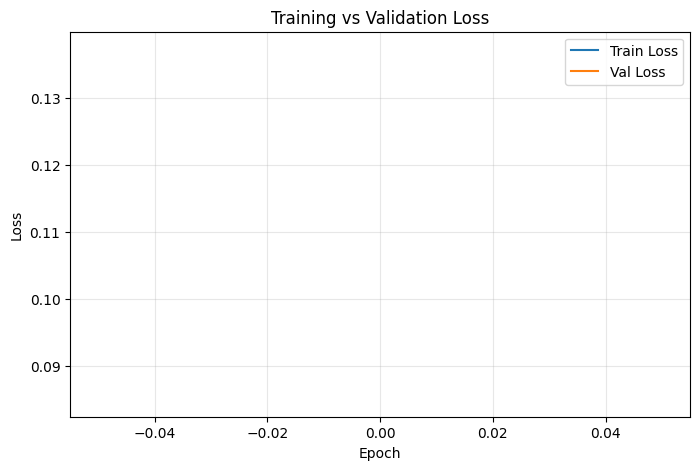

Epoch 2/100 | train_loss: 0.0804 | val_loss: 0.1390 | val_f1: 0.9542 | val_acc: 0.9535


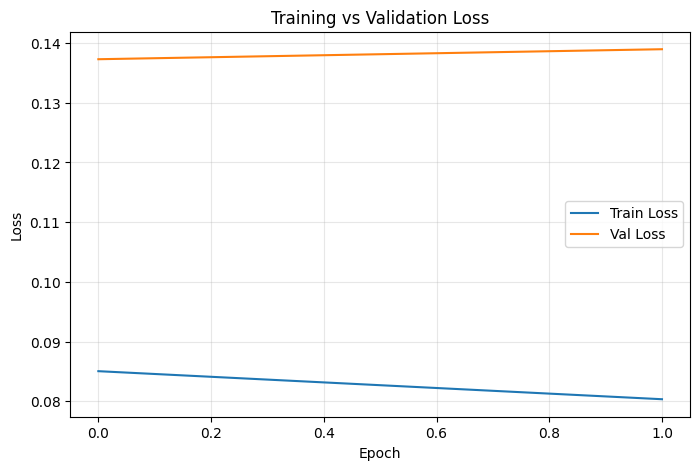

Best epoch: 1 | val_loss: 0.1373 | val_metrics: {'accuracy': 0.9605394601821899, 'auroc': 0.986886203289032, 'f1': 0.9607940316200256, 'precision': 0.9555774927139282, 'recall': 0.9660678505897522}


In [86]:

model = myCNN.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3, weight_decay = 1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

num_epochs = 2
best_val_loss = float("inf")
patience = 10
epochs_no_improve = 0
best_state = None
best_val_metrics = None
best_val_preds = None
best_epoch = None
history_dict = {"train_loss": [], "val_loss": [], "val_accuracy": [], "val_f1": [], "val_precision": [], "val_recall": [], "val_auroc":[],
                "train_accuracy":[],"train_f1":[], "train_precision":[], "train_recall":[], "train_auroc":[]
                }

list_of_run_history = []

best_state_dict= {"run_ID": [], "test_region": [], "val_region": [], "train_loss": [], "val_loss": [], 
                  "val_accuracy": [], "val_f1": [], "val_precision": [], "val_recall": [], "val_auroc":[], }

# ----- loop for outer fold goes here 
# loop for inner fold goes here
run_ID = None


for epoch in range(num_epochs):
    
    train_loss, train_metrics = train_for_one_epoch(model, train_loader, device, aug, optimizer, criterion)
    val_loss, val_metrics, val_preds = val_for_one_epoch(model, val_loader, metrics, device, criterion)

    history_dict["train_loss"].append(train_loss)
    history_dict["val_loss"].append(val_loss)
    history_dict["val_accuracy"].append(val_metrics["accuracy"])
    history_dict["val_f1"].append(val_metrics["f1"])
    history_dict["val_precision"].append(val_metrics["precision"])
    history_dict["val_recall"].append(val_metrics["recall"])
    history_dict["val_auroc"].append(val_metrics["auroc"])
    history_dict["train_accuracy"].append(train_metrics["accuracy"])
    history_dict["train_f1"].append(train_metrics["f1"])
    history_dict["train_precision"].append(train_metrics["precision"])
    history_dict["train_recall"].append(train_metrics["recall"])
    history_dict["train_auroc"].append(train_metrics["auroc"])

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/100 | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} "
          f"| val_f1: {val_metrics['f1']:.4f} | val_acc: {val_metrics['accuracy']:.4f}")
    
    plot_and_save_loss(history_dict, loss_curve_fp)

    # Early stopping

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_train_loss = train_loss
        best_val_metrics = val_metrics
        best_val_preds = val_preds
        best_epoch = epoch
        epochs_no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve +=1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epcoch: {epoch+1}")
            break

model.load_state_dict(best_state)
print(f"Best epoch: {best_epoch+1} | val_loss: {best_val_loss:.4f} | val_metrics: {best_val_metrics}")

run_history_dict = {run_ID: history_dict}
list_of_run_history.append(run_history_dict)

best_state_dict["run_ID"].append(run_ID)
best_state_dict["test_region"].append(test_region)
best_state_dict["val_region"].append(val_region)
best_state_dict["train_loss"].append(train_loss)
best_state_dict["val_loss"].append(best_val_loss)
best_state_dict["val_accuracy"].append(best_val_metrics["accuracy"])
best_state_dict["val_f1"].append(best_val_metrics["f1"])
best_state_dict["val_precision"].append(best_val_metrics["precision"])
best_state_dict["val_recall"].append(best_val_metrics["recall"])
best_state_dict["val_auroc"].append(best_val_metrics["auroc"])




In [90]:
print(len(val_loader.dataset))
print(best_val_preds.shape)
print(type(best_val_preds))
print(history_dict["train_accuracy"])
print(best_state_dict["val_accuracy"])
print(best_state_dict["run_ID"])


2002
torch.Size([2002, 1])
<class 'torch.Tensor'>
[0.9678933024406433, 0.9714332818984985]
[0.9605394601821899]
[None]


Epoch 1/100 | train_loss: 0.0712 | val_loss: 0.1171 | val_f1: 0.9624 | val_acc: 0.9620


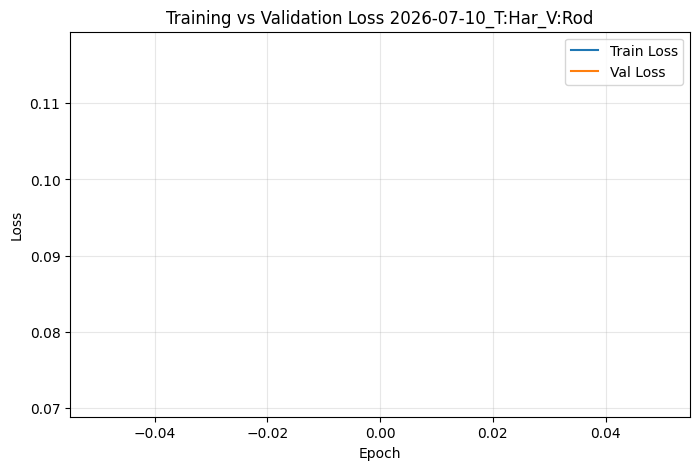

Epoch 2/100 | train_loss: 0.0644 | val_loss: 0.2339 | val_f1: 0.9242 | val_acc: 0.9276


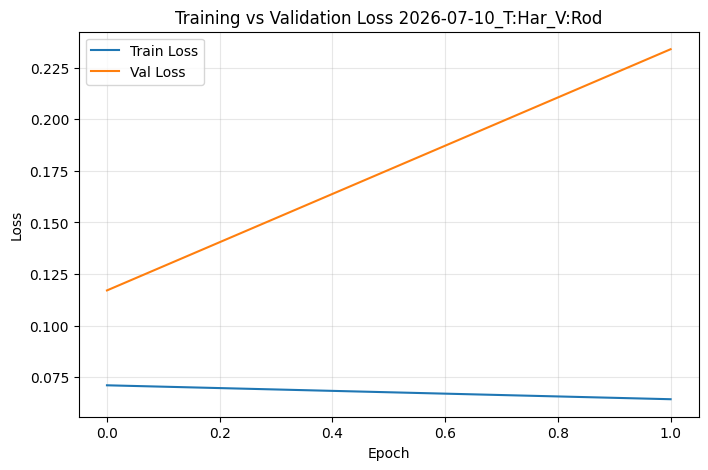

2026-07-10_T:Har_V:Rod
Best epoch: 1 | val_loss: 0.1171 | val_metrics: {'accuracy': 0.962037980556488, 'auroc': 0.9904580116271973, 'f1': 0.9623762369155884, 'precision': 0.9548133611679077, 'recall': 0.970059871673584}
Epoch 1/100 | train_loss: 0.0685 | val_loss: 0.1466 | val_f1: 0.9508 | val_acc: 0.9496


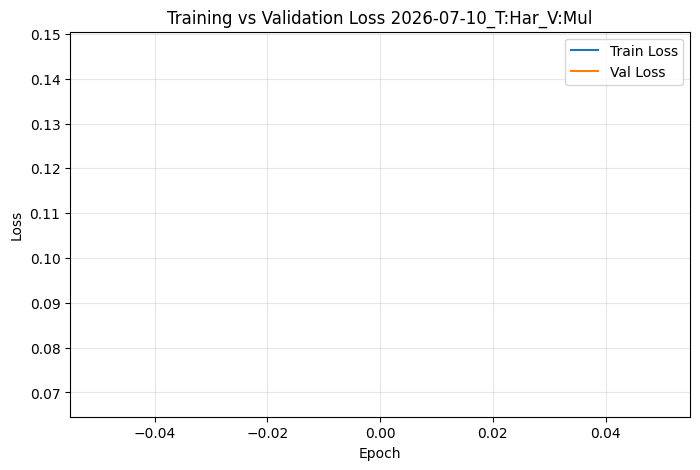

Epoch 2/100 | train_loss: 0.0711 | val_loss: 0.1273 | val_f1: 0.9612 | val_acc: 0.9605


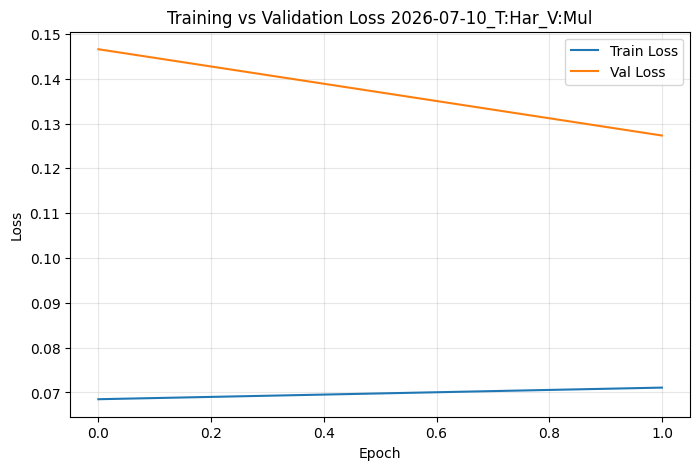

2026-07-10_T:Har_V:Mul
Best epoch: 2 | val_loss: 0.1273 | val_metrics: {'accuracy': 0.9605394601821899, 'auroc': 0.9901527166366577, 'f1': 0.9611793756484985, 'precision': 0.9467570185661316, 'recall': 0.976047933101654}
Epoch 1/100 | train_loss: 0.0725 | val_loss: 0.1177 | val_f1: 0.9601 | val_acc: 0.9595


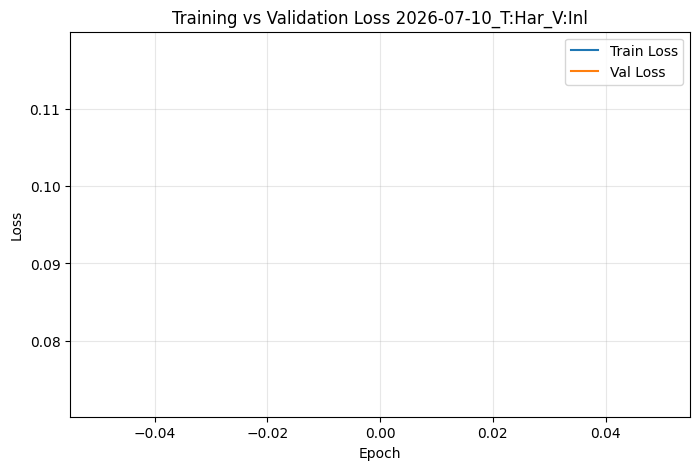

Epoch 2/100 | train_loss: 0.0565 | val_loss: 0.1283 | val_f1: 0.9577 | val_acc: 0.9575


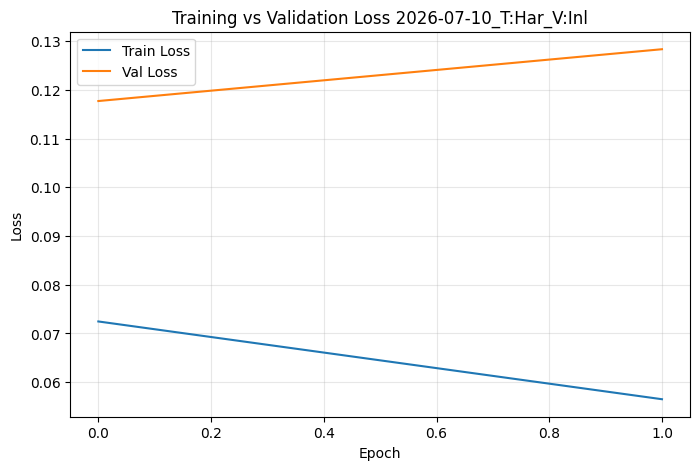

2026-07-10_T:Har_V:Inl
Best epoch: 1 | val_loss: 0.1177 | val_metrics: {'accuracy': 0.9595404863357544, 'auroc': 0.9908382892608643, 'f1': 0.9600788354873657, 'precision': 0.9483934044837952, 'recall': 0.9720559120178223}
Epoch 1/100 | train_loss: 0.0585 | val_loss: 0.1317 | val_f1: 0.9544 | val_acc: 0.9540


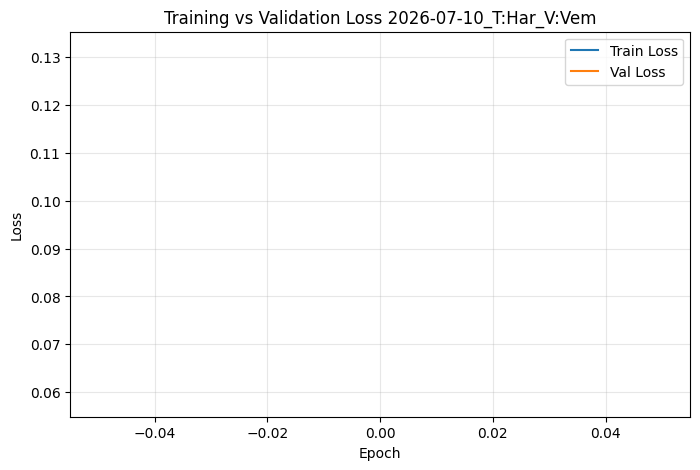

Epoch 2/100 | train_loss: 0.0536 | val_loss: 0.1225 | val_f1: 0.9581 | val_acc: 0.9580


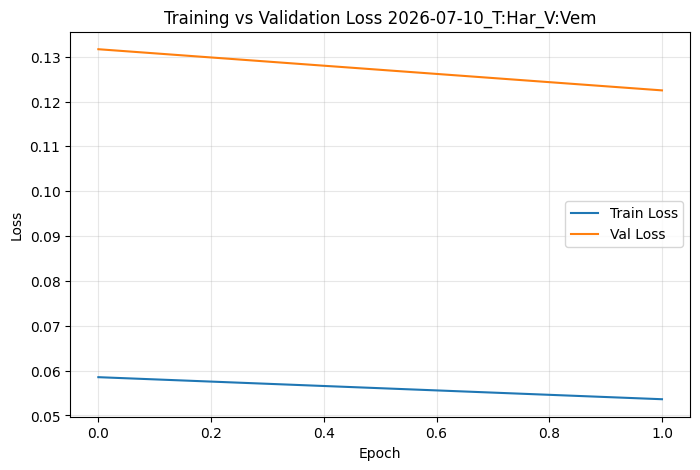

2026-07-10_T:Har_V:Vem
Best epoch: 2 | val_loss: 0.1225 | val_metrics: {'accuracy': 0.9580419659614563, 'auroc': 0.9908642172813416, 'f1': 0.958125650882721, 'precision': 0.9571713209152222, 'recall': 0.9590818285942078}
Epoch 1/100 | train_loss: 0.0531 | val_loss: 0.1280 | val_f1: 0.9622 | val_acc: 0.9620


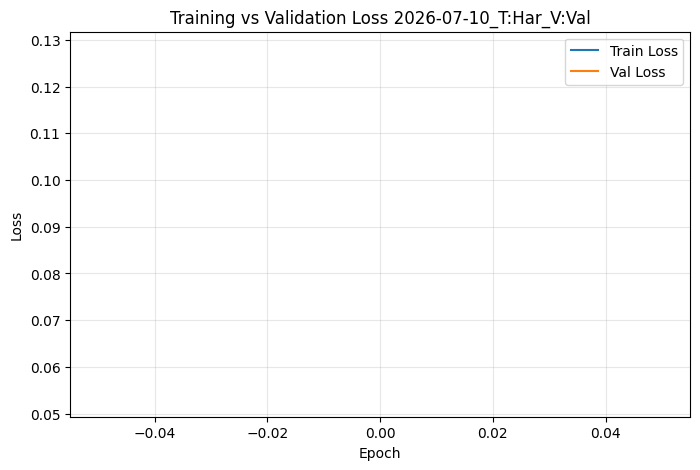

KeyboardInterrupt: 

In [97]:

model = myCNN.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3, weight_decay = 1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

num_epochs = 2
best_val_loss = float("inf")
patience = 10
epochs_no_improve = 0
best_state = None
best_val_metrics = None
best_epoch = None
history_dict = {"train_loss": [], "val_loss": [], "val_accuracy": [], "val_f1": [], "val_precision": [], "val_recall": [], "val_auroc":[],
                "train_accuracy":[],"train_f1":[], "train_precision":[], "train_recall":[], "train_auroc":[]
                }

list_of_run_history = []

best_state_dict= {"run_ID": [], "test_region": [], "val_region": [], "train_loss": [], "val_loss": [], 
                  "val_accuracy": [], "val_f1": [], "val_precision": [], "val_recall": [], "val_auroc":[], }

location_list = ["Hartbeespoort", "Rodman", "Mula", "Inle", "Vembanad", "Valsequillo", "RawaPening", "Winam"]

for location in location_list:
    
    test_region = location
    remaining_regions = [loc for loc in location_list if loc != location]
    test_abrv = test_region[0:3]
    # print(test_abrv)

    for region in remaining_regions:

        val_region = region
        training_regions = [loc for loc in remaining_regions if loc != region]
        val_abrv = val_region[0:3]

        run_ID = date + "_" + f"T:{test_abrv}" + "_" +f"V:{val_abrv}"

        num_epochs = 2
        best_val_loss = float("inf")
        patience = 10
        epochs_no_improve = 0
        best_state = None
        best_val_metrics = None
        best_epoch = None
        history_dict = {"train_loss": [], "val_loss": [], "val_accuracy": [], "val_f1": [], "val_precision": [], "val_recall": [], "val_auroc":[],
                        "train_accuracy":[],"train_f1":[], "train_precision":[], "train_recall":[], "train_auroc":[]
                        }

        for epoch in range(num_epochs):
            
            train_loss,train_metrics = train_for_one_epoch(model, train_loader, device, aug, optimizer, criterion)
            val_loss, val_metrics, val_preds = val_for_one_epoch(model, val_loader, metrics, device, criterion)

            history_dict["train_loss"].append(train_loss)
            history_dict["val_loss"].append(val_loss)
            history_dict["val_accuracy"].append(val_metrics["accuracy"])
            history_dict["val_f1"].append(val_metrics["f1"])
            history_dict["val_precision"].append(val_metrics["precision"])
            history_dict["val_recall"].append(val_metrics["recall"])
            history_dict["val_auroc"].append(val_metrics["auroc"])
            history_dict["train_accuracy"].append(train_metrics["accuracy"])
            history_dict["train_f1"].append(train_metrics["f1"])
            history_dict["train_precision"].append(train_metrics["precision"])
            history_dict["train_recall"].append(train_metrics["recall"])
            history_dict["train_auroc"].append(train_metrics["auroc"])

            scheduler.step(val_loss)

            print(f"Epoch {epoch+1}/100 | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} "
                f"| val_f1: {val_metrics['f1']:.4f} | val_acc: {val_metrics['accuracy']:.4f}")
            
            loss_curve_fp = PROJECT_ROOT / "outputs/plots/loss_curves" / f"{run_ID}.png"
            
            plot_and_save_loss(history_dict, loss_curve_fp, run_ID)

            # Early stopping

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_train_loss = train_loss
                best_val_metrics = val_metrics
                best_val_preds = val_preds
                best_epoch = epoch
                epochs_no_improve = 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                epochs_no_improve +=1
                if epochs_no_improve >= patience:
                    print(f"Early stopping at epcoch: {epoch+1}")
                    break

        model.load_state_dict(best_state)

        print(run_ID)
        print(f"Best epoch: {best_epoch+1} | val_loss: {best_val_loss:.4f} | val_metrics: {best_val_metrics}")

        run_history_dict = {run_ID: history_dict}
        list_of_run_history.append(run_history_dict)

        best_state_dict["run_ID"].append(run_ID)
        best_state_dict["test_region"].append(test_region)
        best_state_dict["val_region"].append(val_region)
        best_state_dict["train_loss"].append(train_loss)
        best_state_dict["val_loss"].append(best_val_loss)
        best_state_dict["val_accuracy"].append(best_val_metrics["accuracy"])
        best_state_dict["val_f1"].append(best_val_metrics["f1"])
        best_state_dict["val_precision"].append(best_val_metrics["precision"])
        best_state_dict["val_recall"].append(best_val_metrics["recall"])
        best_state_dict["val_auroc"].append(best_val_metrics["auroc"])

     

        
    